In [7]:
import pandas as pd  # linear alzebra 
import numpy as np   # data processing 
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
df = pd.read_csv('Social_Network.csv')

In [9]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [10]:
df=df.iloc[:,2:]

In [11]:
df.sample(5)

,Age,EstimatedSalary,Purchased
307,47,113000,1
316,54,104000,1
292,55,39000,1
392,45,45000,1
188,35,72000,0


In [13]:
from sklearn.model_selection import train_test_split 

X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1),
                                                    df['Purchased'],
                                                    test_size=0.3,
                                                    random_state=0)

# Train Test Split (Recommend)

In [13]:
from sklearn.model_selection import train_test_split 

X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1),
                                                    df['Purchased'],
                                                    test_size=0.3,
                                                    random_state=0)

In [15]:
X_train.shape, X_test.shape


((280, 2), (120, 2))

# Standard Scaller 

In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# fit the scaler to train the set, it will learn the parameters
scaler.fit(X_train)

# transform train and test Sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [27]:
X_train

,Age,EstimatedSalary
92,26,15000
223,60,102000
234,38,112000
232,40,107000
377,42,53000
...,...,...
323,48,30000
192,29,43000
117,36,52000
47,27,54000


In [30]:
X_train_scaled # numpy array 

array([[-1.1631724 , -1.5849703 ],
       [ 2.17018137,  0.93098672],
       [ 0.0133054 ,  1.22017719],
       [ 0.20938504,  1.07558195],
       [ 0.40546467, -0.48604654],
       [-0.28081405, -0.31253226],
       [ 0.99370357, -0.8330751 ],
       [ 0.99370357,  1.8563962 ],
       [ 0.0133054 ,  1.24909623],
       [-0.86905295,  2.26126285],
       [-1.1631724 , -1.5849703 ],
       [ 2.17018137, -0.80415605],
       [-1.35925203, -1.46929411],
       [ 0.40546467,  2.2901819 ],
       [ 0.79762394,  0.75747245],
       [-0.96709276, -0.31253226],
       [ 0.11134522,  0.75747245],
       [-0.96709276,  0.55503912],
       [ 0.30742485,  0.06341534],
       [ 0.69958412, -1.26686079],
       [-0.47689368, -0.0233418 ],
       [-1.7514113 ,  0.3526058 ],
       [-0.67297331,  0.12125343],
       [ 0.40546467,  0.29476771],
       [-0.28081405,  0.06341534],
       [-0.47689368,  2.2901819 ],
       [ 0.20938504,  0.03449629],
       [ 1.28782302,  2.20342476],
       [ 0.79762394,

In [47]:
X_trained_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

np.round(X_train.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [48]:
np.round(X_trained_scaled.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


# Effect of Scaling 

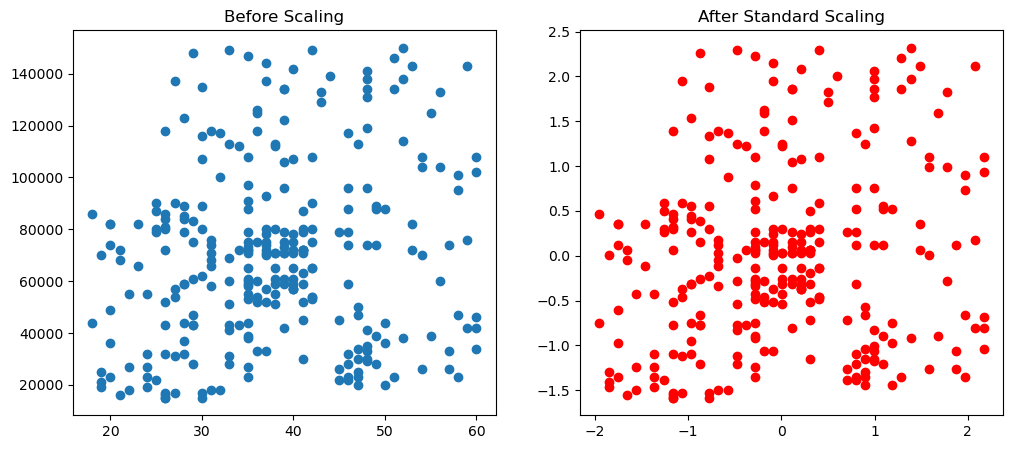

In [62]:
# Create the figure and axes
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Plot 1: Unscaled data
ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")

# Plot 2: Scaled data (using the DataFrame you just created)
ax2.scatter(X_trained_scaled['Age'], X_trained_scaled['EstimatedSalary'], color='red')
ax2.set_title("After Standard Scaling")

# Display the graphs
plt.show()

 probability Density Function (PDF Plot )

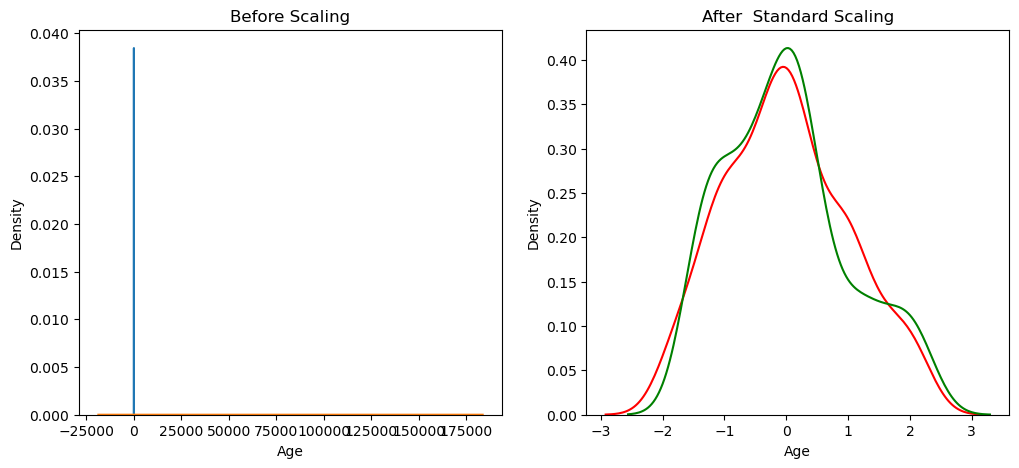

In [61]:
# Fixed: Removed the 'r' in rfig
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Before Scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)
# Fixed: Changed 'kedplot' to 'kdeplot'
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

# After Scaling
ax2.set_title('After  Standard Scaling')
# Fixed: Changed to X_trained_scaled and added colors
sns.kdeplot(X_trained_scaled['Age'], ax=ax2, color='red')
sns.kdeplot(X_trained_scaled['EstimatedSalary'], ax=ax2, color='green')

plt.show()

# Comparison of Distributions

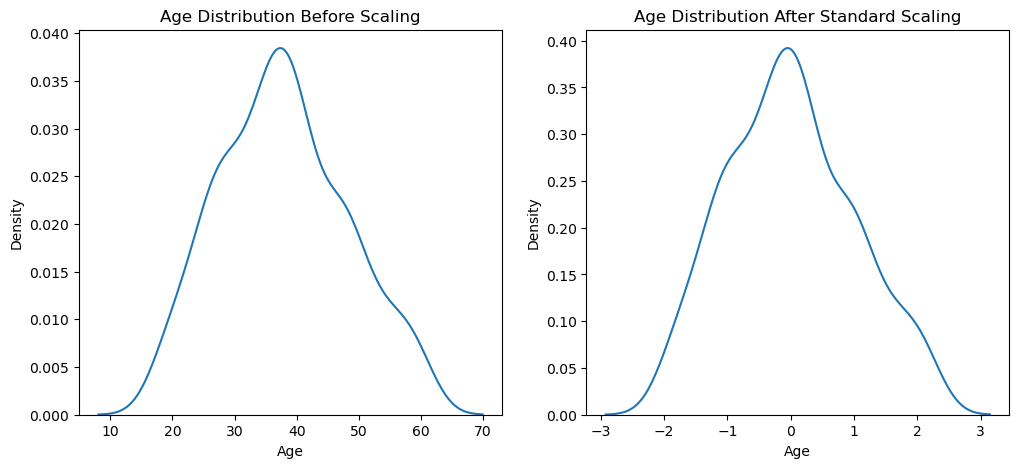

In [67]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before Scalling 
ax1.set_title('Age Distribution Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)

# After Standard Scalling 
ax2.set_title('Age Distribution After Standard Scaling')
sns.kdeplot(X_trained_scaled['Age'], ax=ax2)
plt.show()

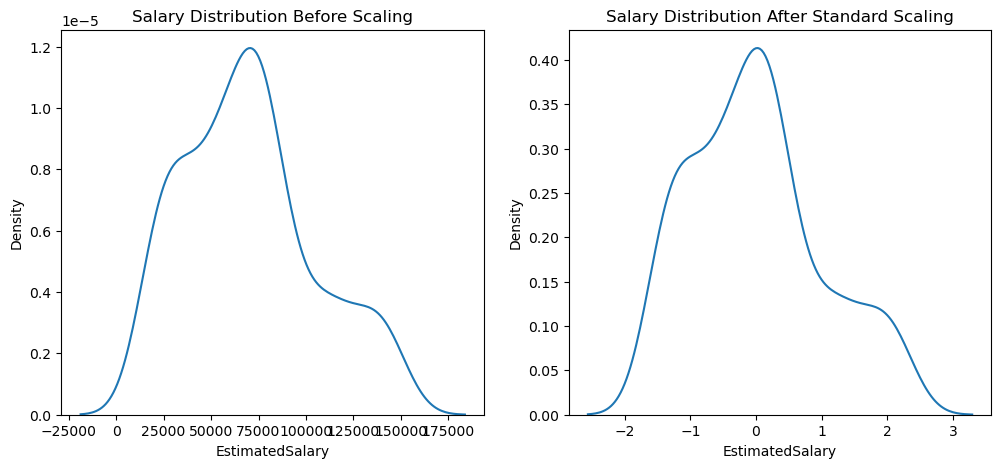

In [68]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before Scalling 
ax1.set_title('Salary Distribution Before Scaling')
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

# After Standard Scalling 
ax2.set_title('Salary Distribution After Standard Scaling')
sns.kdeplot(X_trained_scaled['EstimatedSalary'], ax=ax2)
plt.show()

 # Why Scalling is Important ?

In [70]:
from sklearn.linear_model import LogisticRegression  # Algorithm 

In [72]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [82]:
lr.fit(X_train, y_train)
lr_scaled.fit(X_trained_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [83]:
LogisticRegression()

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [85]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [86]:
from sklearn.metrics import accuracy_score

In [86]:
from sklearn.metrics import accuracy_score

In [87]:
print ("Actual ", accuracy_score(y_test,y_pred))
print ("Scaled ", accuracy_score(y_test,y_pred_scaled))

Actual  0.875
Scaled  0.8666666666666667


In [88]:
from sklearn.metrics import confusion_matrix

print("Before Scaling Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nAfter Scaling Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_scaled))

Before Scaling Confusion Matrix:
[[74  5]
 [10 31]]

After Scaling Confusion Matrix:
[[74  5]
 [11 30]]


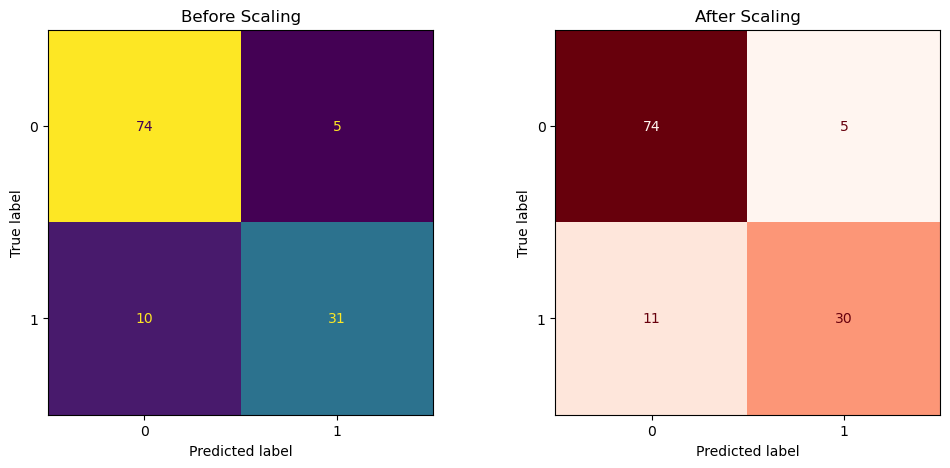

In [93]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create the figure and axes
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Plot 1: Unscaled Matrix (Default Blue/Viridis)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax1, colorbar=False)
ax1.set_title("Before Scaling")

# Plot 2: Scaled Matrix (Red)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_scaled, ax=ax2, colorbar=False, cmap='Reds')
ax2.set_title("After Scaling")

plt.show()

# Also use More Accurate Use KNN 

In [92]:
# 1. Train and predict on UNSCALED (Actual) Data
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)
y_pred_knn_unscaled = knn_unscaled.predict(X_test)

# 2. Train and predict on SCALED Data (What you just did)
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_trained_scaled, y_train)
y_pred_knn_scaled = knn_scaled.predict(X_test_scaled)

# 3. Print both Accuracies
print("KNN Unscaled Accuracy:", accuracy_score(y_test, y_pred_knn_unscaled))
print("KNN Scaled Accuracy:  ", accuracy_score(y_test, y_pred_knn_scaled))

KNN Unscaled Accuracy: 0.825
KNN Scaled Accuracy:   0.9166666666666666


# Using Decision Tree 

In [95]:
from sklearn.tree import DecisionTreeClassifier 

In [120]:
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [121]:
dt.fit(X_train, y_train)
dt_scaled.fit(X_trained_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [122]:
DecisionTreeClassifier()

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [123]:
y_pred = dt.predict(X_test)
y_pred_scaled = dt_scaled.predict(X_test_scaled)

# Both the Actaul and Scale value must be same, Decision can not used on Scalling  So the value is Equal 

In [125]:
print("Actual", accuracy_score(y_test,y_pred))
print("Scaled", accuracy_score(y_test,y_pred_scaled))

Actual 0.875
Scaled 0.875


In [119]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


# Effect of Outlier

In [136]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
404,95,80000,1
405,98,95000,1
406,5,10000,0
407,90,80000,1


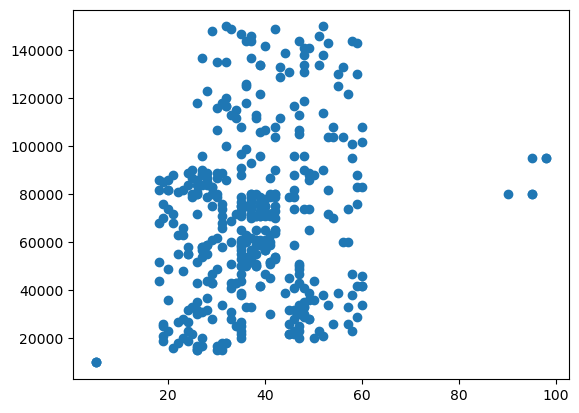

In [137]:
plt.scatter(df['Age'],df['EstimatedSalary'])